# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from collections import OrderedDict

# plt.rcParams["figure.figsize"]=4,4
plt.rcParams["figure.dpi"]=150
# plt.rcParams["savefig.dpi"]=300
plt.rcParams["font.family"] = "Arial"

import warnings
warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import plots_dir, save_dir,cell_types, datasets_e, datasets_a, \
     datasets_all, palette_datasets_pretty, palette_datasets, surrogate_names, \
     colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types, palette_genders, mapping_minor_2_major, palette_disease_effect

from ciim.src.feature_association.helper import retrieve_sig_net, retrieve_feature_data, calculate_tf_activity, compute_trend, retrieve_sig_stats, retrieve_stats_features

from ciim.src.feature_association.plots import plot_net_nx, plot_sig_tfs_stats, plot_analysis_and_centrality, wrapper_drug_aging_overlap
from ciim.src.utils.util import retrieve_adata, get_consensus_net
from ciim.src.utils.plots import dotplot
from ciim.src.feature_association.helper import wrapper_tf_activity, wrapper_gene_expression, wrapper_association_with_age_condition

task_grn_inference_dir = '../../task_grn_inference'


def filter_for_consistent_trends(df):
    consistent_groups = (
        df.groupby(['cell_type', 'tf'])['slope']
        .apply(lambda x: np.sign(x).nunique() == 1)
    )
    valid_tuples = consistent_groups[consistent_groups].index
    filtered_df = df.set_index(['cell_type', 'tf']).loc[valid_tuples].reset_index()
    return filtered_df

# Run TF activity inference

In [48]:
!cd ../ && bash scripts/run_association_analysis.sh

{'type': 'bulk', 'feature_type': 'tf_activity', 'cell_types': ['CD4T', 'CD8T', 'NK', 'B', 'MONO'], 'datasets': ['data1', 'data7_allTPs_jalil', 'data12', 'SLE_European', 'data13_Korean', 'data13_Japanese'], 'association_type': 'spearman', 'cell_type_resolution': 'Major_CT', 'stats_features': '/vol/projects/jnourisa//output//tf_activity/stats_features_bulk.csv', 'stats_all': '/vol/projects/jnourisa//output//tf_activity/stats_all_bulk.csv', 'temp_dir': '/vol/projects/jnourisa//output//tmp/', 'gene_coverage': None}
Calculating TF activity...
Loading data...
Calculating TF activity...
data1 bulk
cell types: 100%|█████████████████████████████████| 5/5 [02:40<00:00, 32.17s/it]
data7_allTPs_jalil bulk
cell types: 100%|█████████████████████████████████| 5/5 [02:31<00:00, 30.39s/it]
data12 bulk
cell types: 100%|█████████████████████████████████| 5/5 [02:27<00:00, 29.58s/it]
SLE_European bulk
cell types: 100%|█████████████████████████████████| 5/5 [02:28<00:00, 29.77s/it]
data13_Korean bulk
cell 

# Pathway gene score

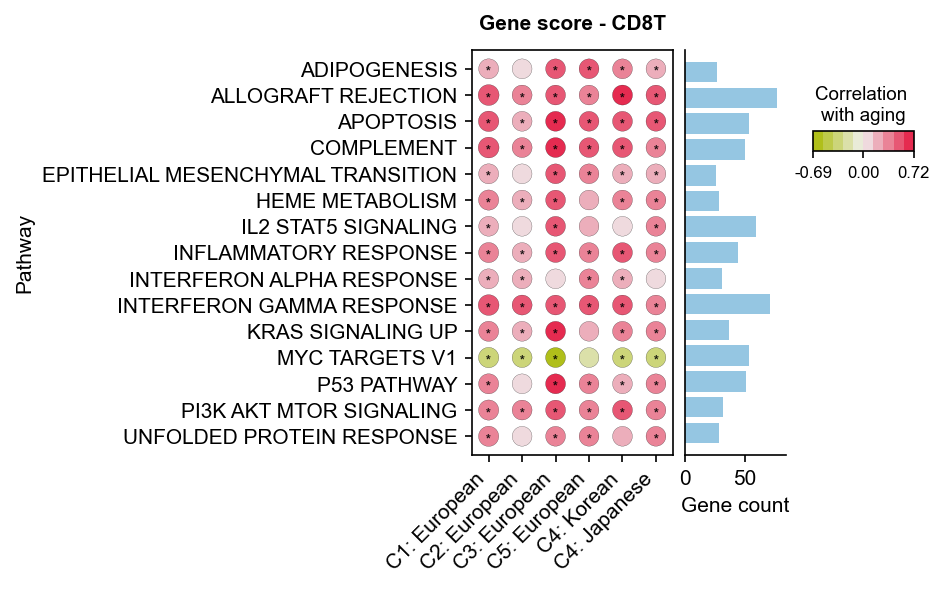

In [204]:
from ciim.src.feature_association.plots import plot_gene_score_association_with_age, plot_features_vs_datasets, plot_feature_values_per_datasets
feature_type='gene_score'
ttypes = ['CD8T']
type = 'bulk'
filter_meta_significant=True
for cell_type in ttypes:
    plot_gene_score_association_with_age(cell_type=cell_type, type=type, datasets=datasets_all, features=None, width=3.5,
                                feature_type=feature_type, sizes=(90, 100), min_degree=1, race='both', 
                                filter_meta_significant=filter_meta_significant,
                                margins_ax1={'x': 0.1, 'y': 0.05}, margins_ax2={'x': 0.1, 'y': 0.03}, figsize=[3.5, 3.5],
                                n_top_terms=15)
    plt.savefig(os.path.join(plots_dir, f'{cell_type}_gene_score_association_with_age.png'), bbox_inches='tight', dpi=300, transparent=True)
    # plot_feature_values_per_datasets(cell_type, features, type, datasets_all, feature_type=feature_type, age_limit=[20, 75], cluster=False, figsize=[10, 2])

In [206]:
retrieve_sig_stats(feature_type='gene_score')['pathway'].unique()

array(['ALLOGRAFT REJECTION', 'ANGIOGENESIS', 'APOPTOSIS',
       'CHOLESTEROL HOMEOSTASIS', 'COAGULATION', 'COMPLEMENT',
       'DNA REPAIR', 'E2F TARGETS', 'GLYCOLYSIS', 'HEME METABOLISM',
       'IL2 STAT5 SIGNALING', 'IL6 JAK STAT3 SIGNALING', 'MYOGENESIS',
       'NOTCH SIGNALING', 'OXIDATIVE PHOSPHORYLATION', 'PEROXISOME',
       'PROTEIN SECRETION', 'REACTIVE OXYGEN SPECIES PATHWAY',
       'UV RESPONSE DN', 'WNT BETA CATENIN SIGNALING',
       'XENOBIOTIC METABOLISM', 'ADIPOGENESIS',
       'EPITHELIAL MESENCHYMAL TRANSITION', 'INFLAMMATORY RESPONSE',
       'INTERFERON ALPHA RESPONSE', 'INTERFERON GAMMA RESPONSE',
       'KRAS SIGNALING UP', 'MYC TARGETS V1', 'MYC TARGETS V2',
       'P53 PATHWAY', 'PANCREAS BETA CELLS', 'PI3K AKT MTOR SIGNALING',
       'UNFOLDED PROTEIN RESPONSE', 'APICAL SURFACE',
       'ESTROGEN RESPONSE EARLY'], dtype=object)

Targeted by Known Rejuvenation Drugs:
	•	PI3K AKT MTOR SIGNALING
→ Targeted by: Rapamycin, everolimus
→ Mechanism: mTOR inhibition; slows aging, enhances autophagy
	•	IL6 JAK STAT3 SIGNALING
→ Targeted by: Ruxolitinib, tofacitinib
→ Mechanism: JAK inhibition; reduces chronic inflammation (inflammaging)
	•	INFLAMMATORY RESPONSE
→ Targeted by: Metformin, JAK inhibitors, NSAIDs
→ Mechanism: General suppression of systemic inflammation
	•	REACTIVE OXYGEN SPECIES PATHWAY
→ Targeted by: Antioxidants, Metformin (indirectly), NAD+ boosters
→ Mechanism: Reduces oxidative stress and mitochondrial damage
	•	OXIDATIVE PHOSPHORYLATION
→ Targeted by: Metformin, NAD+ boosters (NR, NMN)
→ Mechanism: Alters mitochondrial efficiency, boosts respiration
	•	P53 PATHWAY
→ Targeted by: Senolytics (e.g., dasatinib + quercetin)
→ Mechanism: Eliminates p53-driven senescent cells
	•	UNFOLDED PROTEIN RESPONSE
→ Targeted by: Rapamycin (via autophagy), chaperone-enhancing drugs
→ Mechanism: Enhances proteostasis, reduces ER stress
	•	INTERFERON ALPHA/GAMMA RESPONSE
→ Targeted by: JAK inhibitors (e.g., Ruxolitinib)
→ Mechanism: Dampens overactive immune signaling in aging

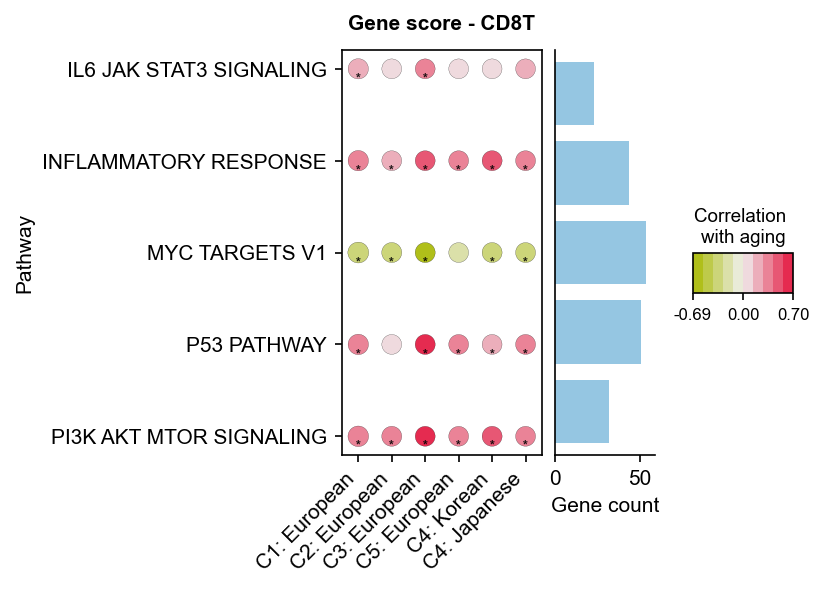

In [207]:
from ciim.src.feature_association.plots import plot_gene_score_association_with_age, plot_features_vs_datasets, plot_feature_values_per_datasets
feature_type='gene_score'
ttypes = ['CD8T']
type = 'bulk'
features = ['MYC TARGETS V1', 'PI3K AKT MTOR SIGNALING', 'IL6 JAK STAT3 SIGNALING', 'INFLAMMATORY RESPONSE', 'P53 PATHWAY', 'INTERFERON ALPHA/GAMMA RESPONSE']
filter_meta_significant=True
for cell_type in ttypes:
    plot_gene_score_association_with_age(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type=feature_type, sizes=(90, 100), min_degree=1, race='both', 
                                filter_meta_significant=filter_meta_significant,
                                margins_ax1={'x': 0.1, 'y': 0.05}, margins_ax2={'x': 0.1, 'y': 0.03}, figsize=[3.5, 3.5],
                                n_top_terms=15)
    plt.savefig(os.path.join(plots_dir, f'{cell_type}_gene_score_association_with_age.png'), bbox_inches='tight', dpi=300, transparent=True)
    # plot_feature_values_per_datasets(cell_type, features, type, datasets_all, feature_type=feature_type, age_limit=[20, 75], cluster=False, figsize=[10, 2])

# Major cell types

## Heatmap of sig TFs across cell types and cohorts

In [8]:
type = 'bulk'
stats_all = retrieve_stats_features(type, feature_type='tf_activity', condition='healthy')

In [9]:
# - add sig signs
stats_sig = retrieve_sig_stats(type)
tuple_index = stats_sig.set_index(['cell_type', 'tf', 'dataset']).index
stats_all = stats_all.set_index(['cell_type', 'tf', 'dataset'])
stats_all['is_significant'] = False
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all = stats_all.reset_index()[['tf', 'cell_type', 'dataset', 'slope', 'is_significant']].drop_duplicates()

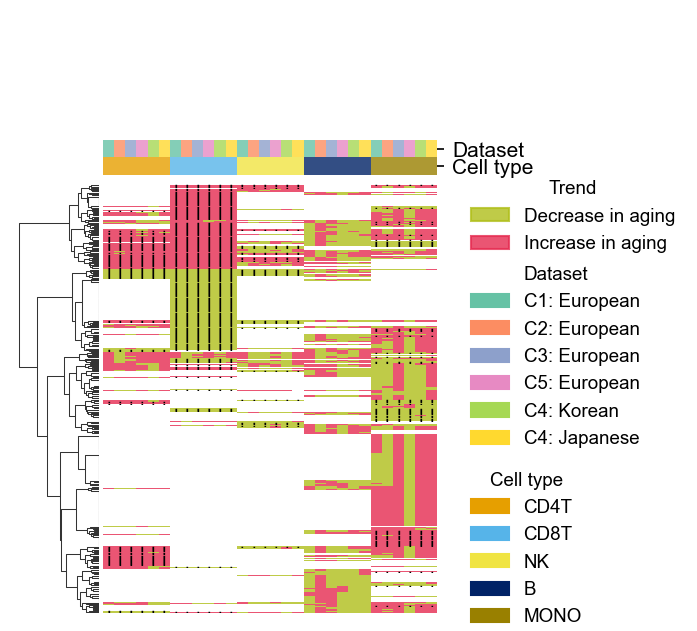

In [10]:
from ciim.src.feature_association.plots import plot_overall_heatmap


stats_all['cell_type'] = pd.Categorical(stats_all['cell_type'], categories=cell_types, ordered=True)
stats_all['dataset'] = pd.Categorical(stats_all['dataset'], categories=datasets_all, ordered=True)

plot_overall_heatmap(stats_all, 
                    sig_dots_y_offset=3, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='dataset', second_col_palette=palette_datasets,
                    bbox_to_anchor=(1.05, 1.05),
                    bbox_to_anchor_col2=(1.05, .85),
                    bbox_to_anchor_col1=(1.05, 0.37),
                    figsize=(4, 6),
                    map_names={**{'cell_type':'Cell type', 'dataset': 'Dataset'}, **surrogate_names})
plt.savefig(f'{plots_dir}//overall_heatmap.png', bbox_inches='tight', dpi=300)

## Sig TFs counts

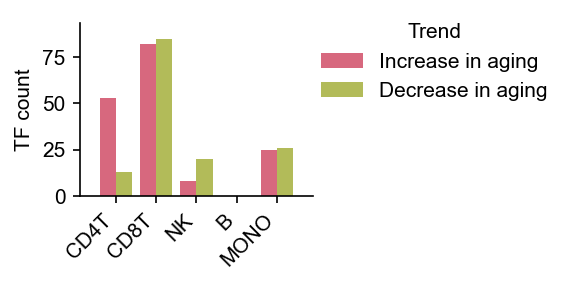

In [11]:
stats = retrieve_sig_stats(type='bulk', filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
# plt.savefig(f'../output/tf_activity/trends.png', dpi=300)
stats['cell_type'] = pd.Categorical(stats['cell_type'], categories=cell_types, ordered=True)
plot_sig_tfs_stats(stats, figsize=(2, 1.5), palette=palette_trend_2)
# plt.title(f'Number of aging TFs', pad=15, fontsize=10, weight='bold')
plt.savefig(f'{plots_dir}//aging_tfs_count.png', bbox_inches='tight', dpi=300, transparent=True)

## Identify sig networks

In [13]:
from ciim.src.feature_association.helper import determine_sig_network

type = 'bulk'

if True:
    determine_sig_network(type, min_degree=3)

FileNotFoundError: [Errno 2] No such file or directory: '/vol/projects/jnourisa//output//gene_expression/stats_all_bulk.csv'

In [224]:
sig_net = retrieve_sig_net()
sig_net_size = sig_net.groupby('cell_type').size()
sig_net_size = sig_net_size.reindex(cell_types, fill_value=0).reset_index()

sig_net_size

,cell_type,0
0,CD4T,3716
1,CD8T,34141
2,NK,764
3,B,19
4,MONO,2058


Text(0.5, 1.0, 'Aging GRNs size')

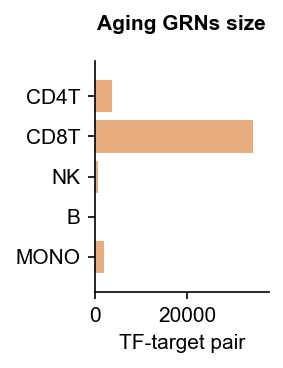

In [225]:
# Reindex to desired order and reset index

sig_net_size.columns = ['cell_type', 'edge_count']

# Ensure categorical order for plotting
sig_net_size['cell_type'] = pd.Categorical(sig_net_size['cell_type'], categories=cell_types, ordered=True)
sig_net_size = sig_net_size.sort_values('cell_type')

# Plot
fig, ax = plt.subplots(figsize=(1.5, 2))
ax.barh(sig_net_size['cell_type'], sig_net_size['edge_count'], color=colors_blind[5], alpha=.5)

# Aesthetics
ax.invert_yaxis()
ax.set_xlabel('TF-target pair')
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.margins(y=0.1, x=0.1)
# ax.set_xscale('log')
ax.set_title('Aging GRNs size', weight='bold', fontsize=10, pad=15)

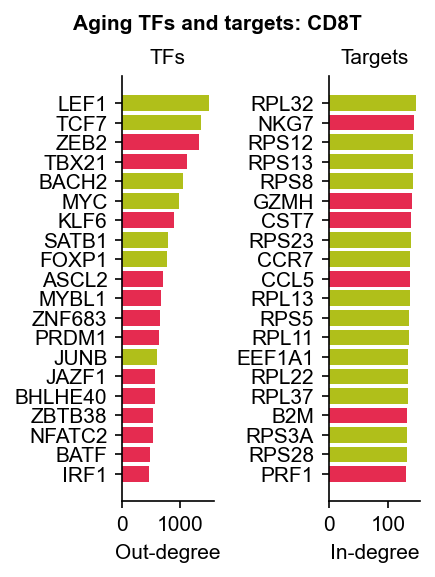

In [226]:
import matplotlib.pyplot as plt

n_top = 20
cell_type = 'CD8T'
df = sig_net[sig_net['cell_type'] == cell_type]

# Compute top source and target degrees
source_counts = df['source'].value_counts().head(n_top).reset_index()
source_counts.columns = ['source', 'degree']
source_info = df[['source', 'trend_source']].drop_duplicates(subset='source')
source_df = source_counts.merge(source_info, on='source', how='left')

target_counts = df['target'].value_counts().head(n_top).reset_index()
target_counts.columns = ['target', 'degree']
target_info = df[['target', 'trend_target']].drop_duplicates(subset='target')
target_df = target_counts.merge(target_info, on='target', how='left')

# Setup plot
fig, axes = plt.subplots(1, 2, figsize=(3, 4), sharey=False)

# Plot sources
source_colors = source_df['trend_source'].map(palette_trend).values
target_colors = target_df['trend_target'].map(palette_trend).values[::-1]
axes[0].barh(source_df['source'], source_df['degree'], color=source_colors)
axes[0].set_title('TFs', fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Out-degree')
axes[0].spines[['top', 'right']].set_visible(False)

# Plot targets
axes[1].barh(target_df['target'][::-1], target_df['degree'][::-1], color=target_colors)
axes[1].set_title('Targets', fontsize=10)
axes[1].set_xlabel('In-degree')
axes[1].spines[['top', 'right']].set_visible(False)

# Title and layout
fig.suptitle(f'Aging TFs and targets: {cell_type}', fontsize=10, weight='bold', y=.95)
from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=color, label=label) for label, color in palette_trend_2.items()]
# fig.legend(handles=legend_elements, bbox_to_anchor=(1.5, .8), fontsize=10, frameon=False, title='Trend', title_fontsize=10)
fig.tight_layout()

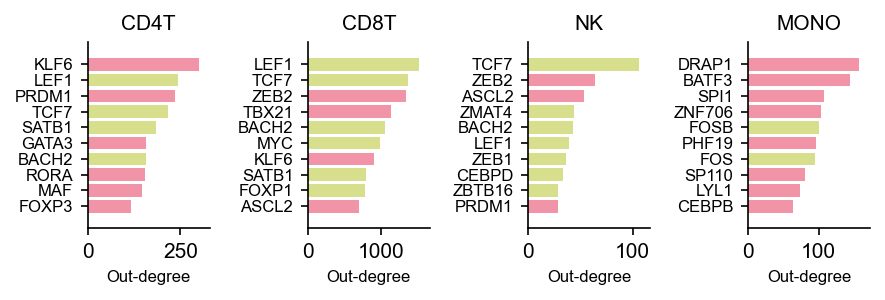

In [234]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Parameters
n_top = 10
cell_types_selected = ['CD4T', 'CD8T', 'NK', 'MONO']
focus = 'source'  # can be 'source' or 'target'
trend_col = 'trend_source' if focus == 'source' else 'trend_target'
palette = palette_trend_2  # assume this dict is defined

# Collect top TFs across cell types
rows = []
for ct in cell_types_selected:
    df_ct = sig_net[sig_net['cell_type'] == ct]
    counts = df_ct[focus].value_counts().head(n_top).reset_index()
    counts.columns = [focus, 'degree']
    trends = df_ct[[focus, trend_col]].drop_duplicates(subset=focus)
    merged = counts.merge(trends, on=focus, how='left')
    merged['cell_type'] = ct
    rows.append(merged)

plot_df = pd.concat(rows, ignore_index=True)

# Sort TFs within each cell type
plot_df[focus] = plot_df[focus].astype(str)
plot_df = plot_df.sort_values(by=['cell_type', 'degree'], ascending=[True, False])

# Setup plot
n_cols = len(cell_types_selected)
fig, axes = plt.subplots(1, n_cols, figsize=(1.5*n_cols, 2.1 ), sharex=False)

if n_cols == 1:
    axes = [axes]

for ax, ct in zip(axes, cell_types_selected):
    df_ct = plot_df[plot_df['cell_type'] == ct]
    colors = df_ct[trend_col].map(palette)
    ax.barh(df_ct[focus], df_ct['degree'], color=colors, alpha=0.5)
    ax.set_title(f'{ct}', fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Out-degree' if focus == 'source' else 'In-degree', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
    ax.margins(x=0.1, y=0.1)
    ax.spines[['top', 'right']].set_visible(False)
# Title and legend
# fig.suptitle(f'Central aging {"TFs" if focus == "source" else "targets"}', fontsize=12, weight='bold', y=0.96)
legend_elements = [Patch(facecolor=color, label=label) for label, color in palette.items()]
# fig.legend(handles=legend_elements, bbox_to_anchor=(1.01, 0.8), loc='upper left', title='Trend', title_fontsize=10, frameon=False)
fig.tight_layout()
plt.savefig(os.path.join(plots_dir, f'central_aging_{focus}.png'), bbox_inches='tight', dpi=300, transparent=True)


## Interaction of aging TFs between cell types

### T cells

In [14]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df

type = 'bulk'
stats_sig = retrieve_sig_stats(type=type).drop_duplicates(subset=['cell_type', 'tf'])
df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)

['CD8T', 'CD4T', 'MONO', 'NK']


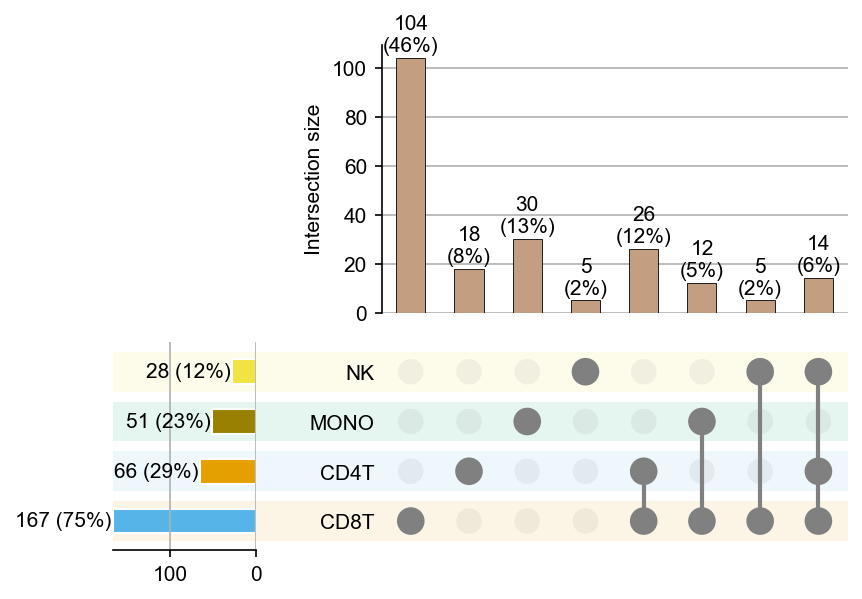

In [15]:
aa = plot_interactions(interaction_main_df, min_subset_size=5, min_degree=1, color_map=palette_cell_types)
plt.savefig(f'{plots_dir}/interactions.png', dpi=300, transparent=True, bbox_inches='tight')
# plt.title(surrogate_names[race], pad=40, fontsize=10, fontweight='bold')

In [16]:
# interaction_main_df.loc['TBX21']

In [17]:
ttypes = ['CD8T', 'CD4T', 'NK']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index.unique()
print(len(features))

15


15


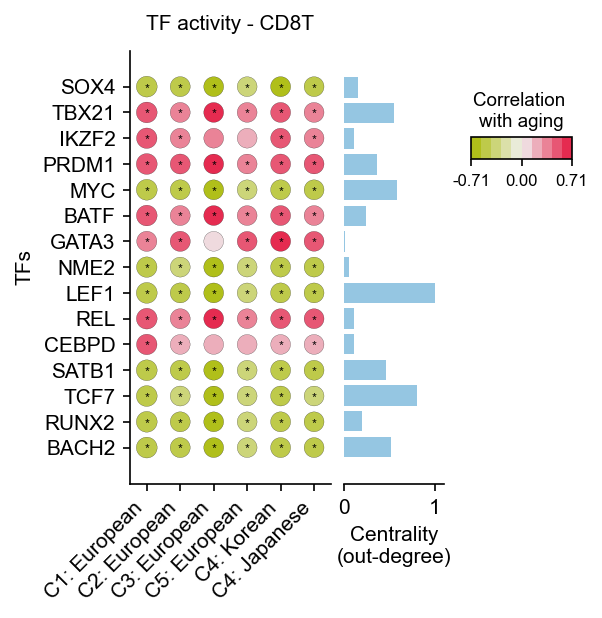

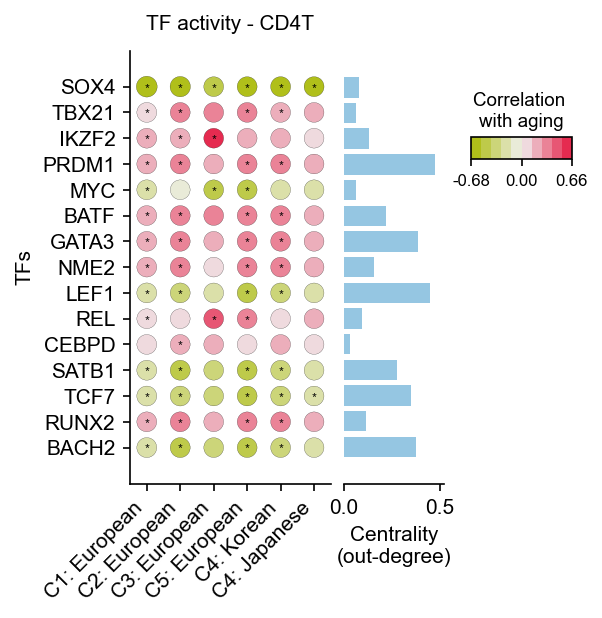

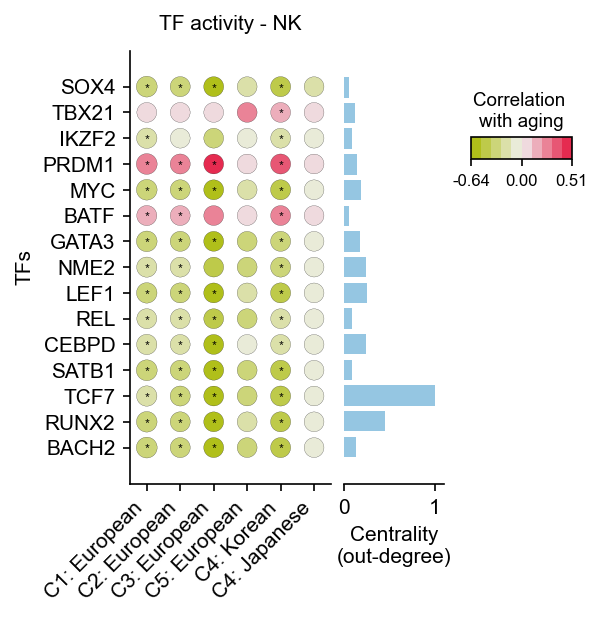

In [19]:
from ciim.src.feature_association.plots import plot_features_vs_datasets

ttypes = ['CD8T', 'CD4T', 'NK']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index.unique()
print(len(features))
for cell_type in ttypes:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(90, 100), min_degree=1, race='both', 
                                filter_meta_significant=True,
                                margins_ax1={'x': 0.1, 'y': 0.1}, margins_ax2={'x': 0.1, 'y': 0.07})
    plt.savefig(f'{plots_dir}//shared_aging_tfs_{cell_type}', bbox_inches='tight', dpi=300, transparent=True)

### Shared sig TFs between CD8T and CD4T

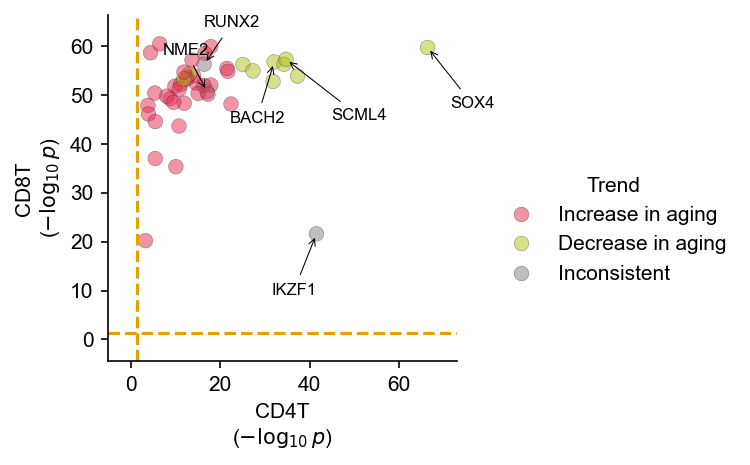

In [20]:
from ciim.src.feature_association.plots import plot_joint_scatter

ttypes = ['CD8T', 'CD4T']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(features)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
plot_joint_scatter(df, vars=['CD4T', 'CD8T'], annotate=True, ax=ax)
ax.margins(x=0.1, y=0.1)

## GSEA

In [21]:
from ciim.src.utils.util import pathway_analysis_wrapper
type = 'bulk'
feature_type = 'tf_activity'
race = 'both'
pathway_scores_store = []

stats_sig = retrieve_sig_stats(type, race=race)

pathway_scores = pathway_analysis_wrapper(stats_sig)
pathway_scores['race'] = race
pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])


(6, 10)
(4, 10)
(6, 10)
(2, 10)
(1, 10)
(7, 10)
(4, 10)
(8, 10)


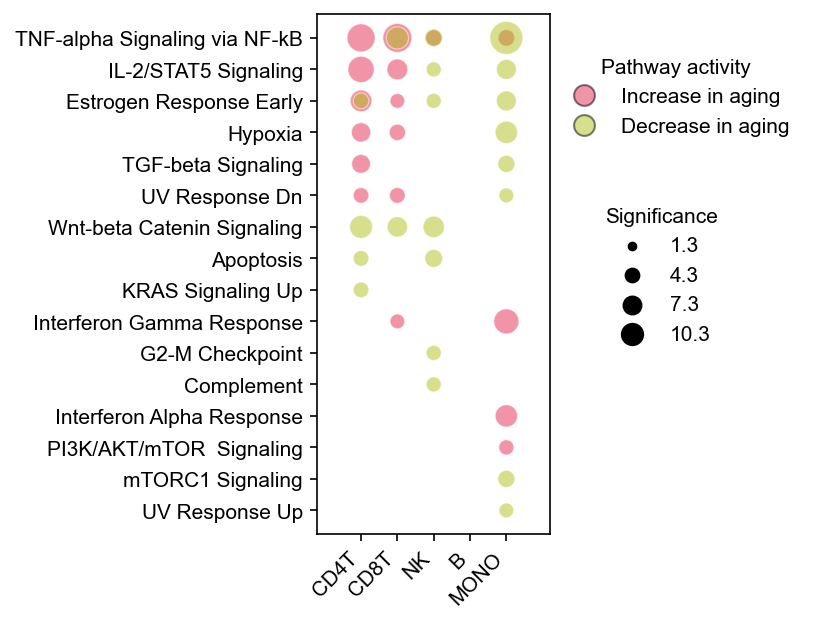

In [22]:
from ciim.src.feature_association.plots import dotplot_category_color
from ciim.src.common import surrogate_names
    
fig, ax = plt.subplots(1, 1, figsize=(2, 4.5), sharey=True, sharex=True)

pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
show_color_legend = True
show_size_legend = True

dotplot_category_color(pathway_scores, 
            ax, 
            color_col='trend', 
            size_col='neg_log10_adj_pval', 
            x='cell_type', 
            y='Term', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=show_color_legend, 
            show_size_legend=show_size_legend,
            size_legend_title='Significance',
            color_legend_title='Pathway activity',
            size_legend_loc=(1.2, 0.35),
            color_legend_loc=(1.02, 0.75),
            y_label='',
            alpha=0.5)
# ax.set_title(surrogate_names[race], fontsize=10, fontweight='bold')

In [23]:
pathway_scores['Term'].unique()

array(['TNF-alpha Signaling via NF-kB', 'IL-2/STAT5 Signaling',
       'Estrogen Response Early', 'Hypoxia', 'TGF-beta Signaling',
       'UV Response Dn', 'Wnt-beta Catenin Signaling', 'Apoptosis',
       'KRAS Signaling Up', 'Interferon Gamma Response',
       'G2-M Checkpoint', 'Complement', 'Interferon Alpha Response',
       'PI3K/AKT/mTOR  Signaling', 'mTORC1 Signaling', 'UV Response Up'],
      dtype=object)

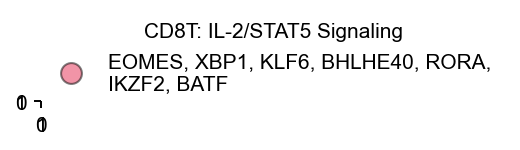

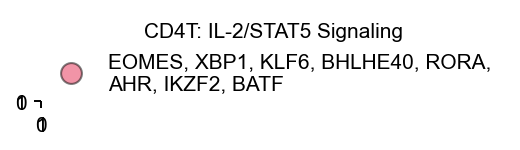

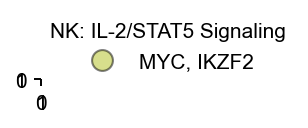

In [24]:
# - the term with bifurcation enrichment
term = 'IL-2/STAT5 Signaling'
cell_type = 'CD8T'

from ciim.src.feature_association.plots import plot_term_genes
for cell_type in ['CD8T', 'CD4T', 'NK']:
    plot_term_genes(pathway_scores, cell_type, term)

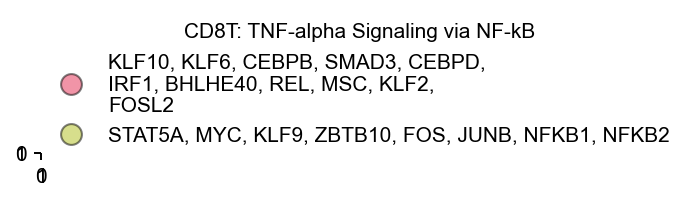

In [25]:
# - the term with bifurcation enrichment
term = 'TNF-alpha Signaling via NF-kB'
cell_type = 'CD8T'

from ciim.src.feature_association.plots import plot_term_genes

plot_term_genes(pathway_scores, cell_type, term)


In [28]:
from ciim.src.utils.util import get_genesets
pathways = get_genesets(pathway='hallmark')
for key in pathways.keys():
    if 'STAT5' in key:
        print(key)

IL-2/STAT5 Signaling


In [29]:
if False:
    features = pathway_scores_all[(pathway_scores_all['Term']==term) & (pathway_scores_all['cell_type']==cell_type)].groupby('trend')['Genes'].apply(lambda x: x.str.split(';')).explode().unique()
    from ciim.src.feature_association.plots import plot_features_vs_datasets
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)


# Case TF

In [5]:
case_tf = 'SATB1'  # 'TCF7' 'SATB1' 
type = 'bulk'
race = 'both'
n_top_targets = 10
selected_cell_types = ['CD8T', 'CD4T', 'NK'] # ['CD8T', 'CD4T', 'NK'] #Tcm_Naive_CD8
n_panels = len(selected_cell_types)

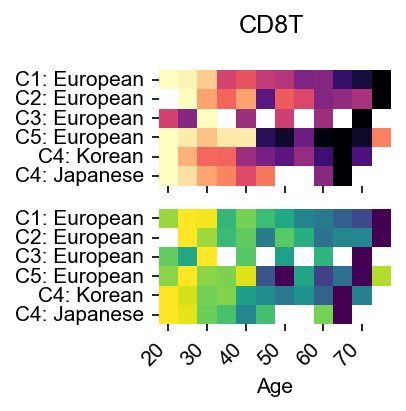

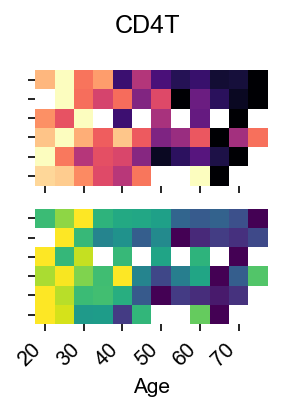

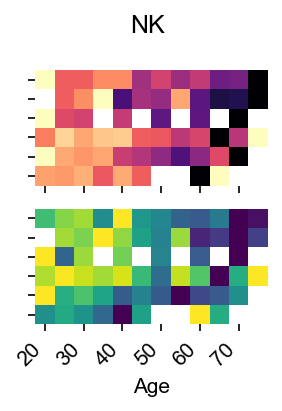

In [6]:
from ciim.src.feature_association.plots import plot_feature_values_all_datasets, plot_feature_values_per_datasets
type = 'bulk'

if '_M' in type:
    datasets = ['data1', 'data7_allTPs_jalil', 'data13_Korean']
elif '_F' in type:
    datasets = ['data1', 'SLE_European', 'data13_Korean']
else:
    # datasets = ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Korean']
    datasets = datasets_all

plot_both = True
show_cbar=False


for i, cell_type in enumerate(selected_cell_types):
    if i == 0:
        show_ylabels=True
    else:
        show_ylabels=False
    
    if plot_both:
        fig, axes = plt.subplots(2, 1, figsize=(2, 2.2), sharex=True)
    else:
        fig, ax = plt.subplots(1, 1, figsize=(2, .7))

    ax = axes[0] if plot_both else ax
    plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type='tf_activity', type=type, datasets=datasets, show_cbar=show_cbar, ax=ax,
                                     show_ylabels=show_ylabels)
    if plot_both:
        ax.set_xlabel('')
        ax = axes[1]
        plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type='gene_expression', 
                                        type=type, datasets=datasets, show_cbar=show_cbar, ax=ax, show_ylabels=show_ylabels)
    
    plt.suptitle(f'{cell_type}', y=1.05)
    plt.savefig(f'{plots_dir}/{case_tf}_{cell_type}.png', bbox_inches='tight', dpi=300)

In [7]:
nets_sig = pd.read_csv(f'{save_dir}/sig_nets/sig_nets_{type}_{race}.csv')
nets_sig = nets_sig[(nets_sig['source']==case_tf) & (nets_sig['cell_type'].isin(selected_cell_types))].copy()
n_targets = 10

FileNotFoundError: [Errno 2] No such file or directory: '/vol/projects/jnourisa//output//sig_nets/sig_nets_bulk_both.csv'

In [218]:
stats_targets = retrieve_sig_stats(type, feature_type='gene_expression', race=race)

targets_store = []
for cell_type in selected_cell_types:
    net = nets_sig[nets_sig['cell_type']==cell_type]
    targets = net.sort_values('weight', ascending=False, key=abs).head(n_targets)['target'].unique()
    targets_store.append(targets)
all_targets = np.concatenate(targets_store)


def select_top_targets(cell_type, tf, n_top=30):
    net_store = []
    for dataset in datasets:
        net = retrieve_net(dataset, cell_type)
        net = net[(net['source']==tf) & (net['target'].isin(all_targets))].copy()
    
        #- select targets
        stats = stats_targets[(stats_targets['target'].isin(all_targets)) & (stats_targets['dataset']==dataset) & (stats_targets['cell_type']==cell_type)]
        net = net.merge(stats[['target', 'p_value_adj', 'slope']], on='target', how='left')
        net['neg_log10_adj_pval'] = -np.log10(net['p_value_adj'])
        net['dataset'] = dataset

        net_store.append(net)
    net_tf = pd.concat(net_store)
    return net_tf

net_store = []
for cell_type in selected_cell_types:
    net = select_top_targets(cell_type, case_tf, n_top=n_top_targets)
    net['cell_type'] = cell_type
    net_store.append(net)
net_tf = pd.concat(net_store)

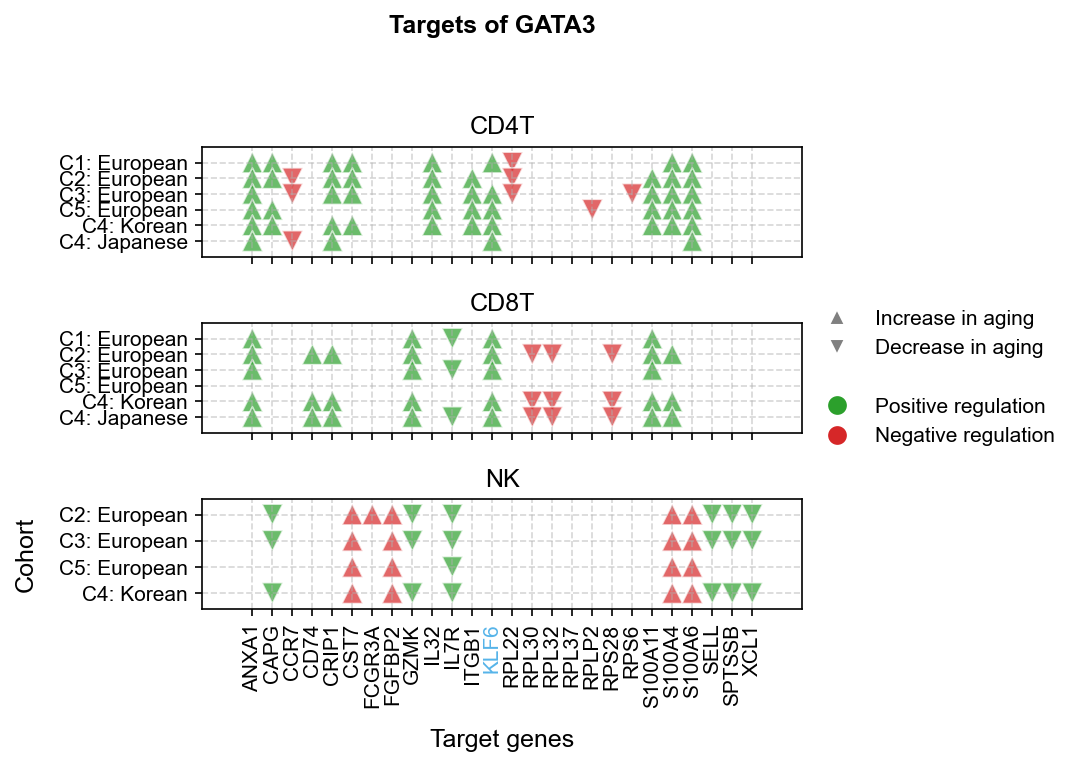

In [219]:
from ciim.src.feature_association.plots import wrapper_flesh_out_tf_interactions, plot_tf_interactions_plus_target_stats_binary

n_top_genes_per_dataset=10
# - select 
shared_state = net_tf.groupby(['cell_type','target'])['dataset'].nunique()
selected_tuple = shared_state[shared_state>=3].index
net_tf = net_tf.set_index(['cell_type', 'target']).loc[selected_tuple].reset_index()

n_targets = net_tf['target'].nunique()
net_tf['target'] = net_tf['target'].astype('category')
net_tf['dataset'] = pd.Categorical(net_tf['dataset'], categories=datasets_all, ordered=True)
fig, axes = plt.subplots(n_panels, 1, figsize=(n_targets*.16 +1, len(datasets_all)*.5 + 1), sharex=True)

for i, (cell_type) in enumerate(net_tf['cell_type'].unique()):
    ax = axes[i] if n_panels > 1 else axes
    if i == 1:
        show_legend = True
    else:
        show_legend = False
    net = net_tf[net_tf['cell_type'] == cell_type]   
    net = net[net['neg_log10_adj_pval'] > 1.4]
    
    plot_tf_interactions_plus_target_stats_binary(net.copy(), ax=ax, show_legend=show_legend, sizes=(50, 200), annotate_sig=False, annotate_targets=True)

    ax.margins(y=0.2, x=0.1)
    ax.set_title(cell_type)
    ax.set_xlabel('Target genes')
    ax.grid(True, linestyle='--', alpha=0.5)
    if i != n_panels - 1:
        ax.set_ylabel('')
plt.suptitle(f'Targets of {case_tf}', y=1.1, weight='bold', fontsize=12)
plt.subplots_adjust(hspace=0.6)

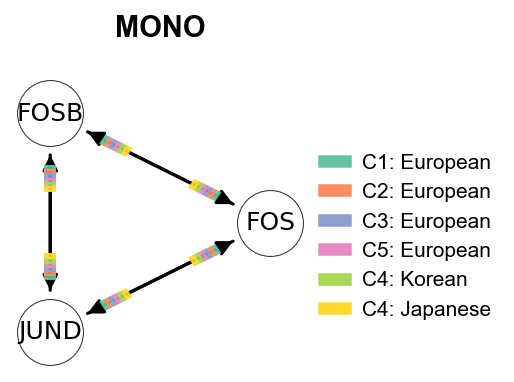

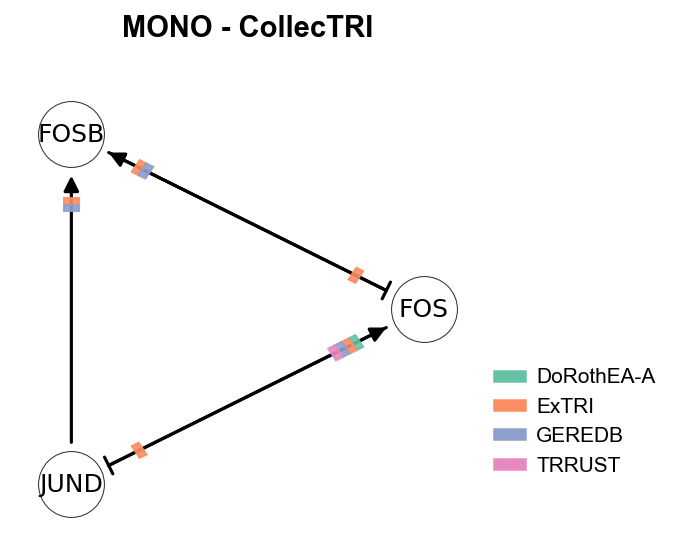

In [220]:
type = 'bulk'
cell_type = 'CD4T' #'Tcm_Naive_CD8'
n_top=10
# features = ['FOXO1', 'FOXO3', 'NFE2L2', 'TP53', 'SIRT1', 'HIF1A']
# features = ['GATA3', 'S100A4', 'GZMK', 'KLF6', 'COTL1', 'TCF7', 'ANXA1']
# features = ['GATA3', 'S100A4', 'GZMK', 'COTL1']
features = ['FOS', 'FOSB', 'JUND']
from ciim.src.feature_association.plots import wrapper_draw_net
for cell_type in ['MONO']:
    wrapper_draw_net(cell_type, datasets_all, features, min_degree=3, indivitual_net=False, draw_evidence=True, draw_collectri=True, figsize=(2.5, 2.5), figsize_collectri=(4, 4), 
                    offset_evidence=.13, arc_offset=.05, only_promotor_based=False)

# Disease

In [2]:
type = 'bulk'
test_type= 'unpaired' #'mixed-effect'
dataset = 'SLE_European' #'SLE_European' Covid_50MHH
feature_type= 'tf_activity' #'tf_activity' gene_expression


In [4]:
if dataset == 'SLE_European':
    disease_name = 'SLE'
else:
    disease_name = 'COVID 19'

disease_name = dataset.split('_')[0]
if True:
    os.makedirs(f'{save_dir}/stats', exist_ok=True)
    par = {
        'feature_type':feature_type, 
        'datasets': [dataset],
        'type': type,
        'cell_types': cell_types,
        'cell_type_resolution': 'Major_CT',
        'association_type': 'spearman'
    }
    if True:
        if feature_type == 'tf_activity':
            wrapper_tf_activity(par)
        else:
            wrapper_gene_expression(par)
    stats_disease = wrapper_association_with_age_condition(par, features=None, test_type=test_type, condition=None)
    stats_disease.to_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')
else:
    stats_disease = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')

Loading data...
Calculating TF activity...
SLE_European bulk


cell types:   0%|          | 0/5 [00:00<?, ?it/s]Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1501e41906a0>>
Traceback (most recent call last):
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
cell types: 100%|██████████| 5/5 [02:42<00:00, 32.51s/it]


Association tf_activity with age/disease...


cell types: 100%|██████████| 5/5 [00:19<00:00,  3.93s/it]

['CD4T' 'CD8T' 'NK' 'B' 'MONO']


In [7]:
from ciim.src.common import mapping_minor_2_major
stats_disease = stats_disease[(~stats_disease['slope_condition'].isna())].copy()
stats_disease_sig = stats_disease[stats_disease['p_value_adj'] < 0.05].copy()
stats_disease_sig['major_cell_type'] = stats_disease_sig['cell_type'].apply(lambda x: mapping_minor_2_major.get(x, x))

stats_disease_sig.groupby(['cell_type'])['tf'].nunique()

cell_type
B       112
CD4T    115
CD8T    175
MONO    164
NK       56
Name: tf, dtype: int64

## Overview

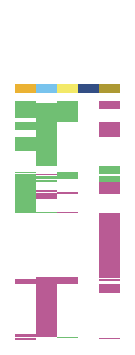

In [34]:
# - plot
from ciim.src.feature_association.plots import heamap_plot_minor_cell_types
from ciim.src.common import palette_disease_effect

if 'minor' in type:
    ordered_cell_names = [
                        'Tcm_Naive_CD4',
                        'Tem_Effector_CD4',
                        
                        'Tcm_Naive_CD8',
                        'Tem_Trm_CD8',
                        'Tem_Temra_CD8',
                        'MAIT',

                        'NK',
                        'CD16_NK',

                        'Classic_MONO',
                        'NonClassic_MONO',
                        
                        'Naive_B',
                        'Memory_B',
                        ]
    stats_disease_sig = stats_disease_sig[stats_disease_sig['cell_type'].isin(ordered_cell_names)]
    stats_disease_sig['cell_type'] = pd.Categorical(stats_disease_sig['cell_type'], categories=ordered_cell_names, ordered=True)
    stats_disease_sig['major_cell_type'] = stats_disease_sig['major_cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))

    stats_disease_sig_all = stats_disease_sig[stats_disease_sig['age_group']=='all']
    heamap_plot_minor_cell_types(stats_disease_sig_all, slope_col='slope_condition', palette=palette_disease_effect, figsize=(5, 7), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Major cell type'})
else:
    stats_disease_sig['cell_type'] = pd.Categorical(stats_disease_sig['cell_type'], categories=cell_types, ordered=True)
    stats_disease_sig['major_cell_type'] = stats_disease_sig['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))
    stats_disease_sig_all = stats_disease_sig[stats_disease_sig['age_group']=='Both age groups']
    heamap_plot_minor_cell_types(stats_disease_sig_all, slope_col='slope_condition', palette=palette_disease_effect, figsize=(2, 3), 
                                sig_dots_y_offset=3, annotate_x_ticks=False, map_names={'cell_type':'Sub type', 'major_cell_type':'Cell type'},
                                dendrogram_visible=False, show_legend=False)
plt.savefig(f'{plots_dir}/overview_sle.png', bbox_inches='tight', dpi=300, transparent=True)

## Aging TFs and disease

In [5]:
type = 'bulk'
aging_stats_sig = retrieve_sig_stats(type, race='both').drop_duplicates(subset=['cell_type', 'tf'])
aging_stats_sig = aging_stats_sig[['tf', 'cell_type', 'slope']]

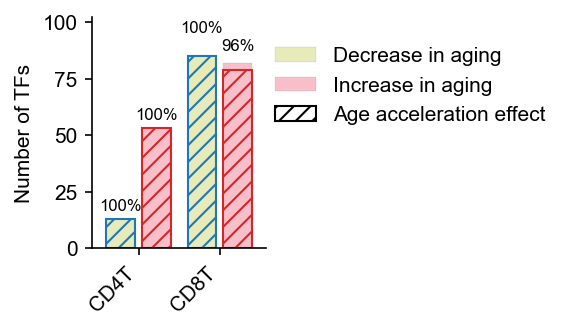

In [10]:
agreement = 'same'
included_cell_types = ['CD4T', 'CD8T']
stats_disease_sig = stats_disease_sig[stats_disease_sig['cell_type'].isin(included_cell_types)].copy()
stats_disease_sig['cell_type'] = pd.Categorical(stats_disease_sig['cell_type'], categories=included_cell_types, ordered=True)

wrapper_drug_aging_overlap(stats_disease_sig[['tf','cell_type', 'slope_condition']], aging_stats_sig[['tf','cell_type', 'slope']], 
                            col='cell_type', how='left', agreement=agreement, legend=True, figsize=(1.5, 2), legend_loc=(1, 0.5))
# plt.title(f'Pathological aging TFs in {disease_name}', fontsize=10, fontweight='bold', pad=15)
plt.savefig(f'{plots_dir}//disease_aging_overlap_{disease_name}_{type}.png', bbox_inches='tight', dpi=300, transparent=True)

In [12]:
stats_disease['age_group'].unique()

array(['Both age groups', 'Younger than 50', 'Older than 50'],
      dtype=object)

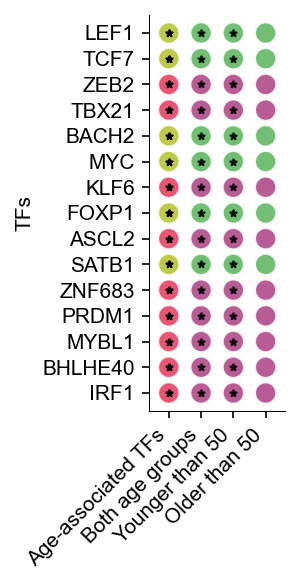

In [43]:
from ciim.src.common import palette_trend, palette_disease_effect, surrogate_names
palette_all = {**palette_trend, **palette_disease_effect}
top_aging_tfs = 15
age_groups = stats_disease['age_group'].unique()



stats_disease['dataset'] = stats_disease['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in ['CD8T']:
    # --- Aging TFs ---
    aging_df = aging_stats_sig[aging_stats_sig['cell_type'] == cell_type]
    net = get_consensus_net(datasets_all, cell_type)
    c_df = net.groupby('source').size().reset_index(name='degree')
    aging_df = aging_df.merge(c_df, left_on='tf', right_on='source', how='left')[['tf', 'slope', 'degree']]
    aging_df['degree'] = aging_df['degree'].div(aging_df['degree'].max())  # Normalize degree
    aging_df['trend'] = ['Increase in aging' if x > 0 else 'Decrease in aging' for x in aging_df['slope']]
    aging_df['analysis'] = 'Age-associated TFs'

    # --- Disease TFs ---
    stats_store = []
    for age_group in age_groups:
        stats_d = stats_disease[
            (stats_disease['age_group'] == age_group) &
            (stats_disease['cell_type'] == cell_type) &
            (~stats_disease['slope_condition'].isna())
        ].copy()
        stats_d = stats_d[['tf', 'cell_type', 'slope_condition', 'p_value_adj']].drop_duplicates()
        stats_d['analysis'] = age_group
        stats_d['trend'] = ['Increase in disease' if x > 0 else 'Decrease in disease' for x in stats_d['slope_condition']]
        stats_store.append(stats_d)

    stats_condition = pd.concat(stats_store)
    stats_condition['analysis'] = stats_condition['analysis'].astype(pd.CategoricalDtype(categories=age_groups, ordered=True))

    # --- Restrict to overlapping TFs ---
    common_tfs = set(aging_df['tf']) & set(stats_condition['tf'])
    aging_df = aging_df[aging_df['tf'].isin(common_tfs)]


    # Order TFs by degree (descending: top = most central)
    top_tfs = aging_df.sort_values('degree', ascending=False).head(top_aging_tfs)['tf'].unique()
    tf_order = list(top_tfs)  # already in correct top-to-bottom order

    # --- Combine and filter ---
    aging_df = aging_df[aging_df['tf'].isin(top_tfs)]
    stats_combined = pd.concat([aging_df, stats_condition])
    df = stats_combined[stats_combined['tf'].isin(top_tfs)].copy()
    # Set TF categorical order
    df['tf'] = pd.Categorical(df['tf'], categories=tf_order, ordered=True)
    plot_analysis_and_centrality(df, all_groups=age_groups,  figsize=(2.1, 4), palette_all=palette_all, plot_centrality=False, show_legend=False)
    # - Title and save
    # plt.suptitle(f'{disease_name} ({cell_type})', y=.97, weight='bold')
    plt.tight_layout()
    plt.savefig(f'{plots_dir}/aging_{disease_name}_overlap_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)

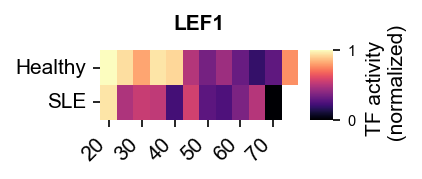

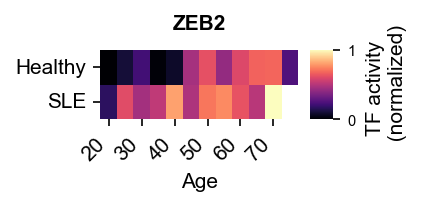

In [14]:
from ciim.src.feature_association.plots import heatplot_age_trend
from collections import defaultdict
from ciim.src.common import surrogate_names


def format_tf_activity_for_disease_trend_plot(dataset, type, cell_type, tf, age_limit=[20, 75], condition_col='disease'):
    tf_acts = retrieve_feature_data(dataset, cell_type, type=type, condition=None)
    tf_acts = tf_acts[(tf_acts.obs['age'] >= age_limit[0]) & (tf_acts.obs['age'] <= age_limit[1])]
    tf_acts = tf_acts[:, tf_acts.var_names == tf]
    if tf_acts.shape[1]==0:
        return None

    expr = tf_acts.to_df()
    expr = expr.merge(tf_acts.obs[['age', condition_col]], left_index=True, right_index=True, how='left')
    expr[condition_col] = expr[condition_col].astype('category')
    expr['age'] = expr['age'].astype(int)

    # Pivot table: rows = disease, columns = age, values = expression
    expr_table = expr.pivot_table(index=condition_col, columns='age', values=tf)

    # Bin ages into 5-year intervals
    df = expr_table.copy()
    age_columns = df.columns
    age_bins = defaultdict(list)

    for col in age_columns:
        bin_start = (col // 5) * 5
        age_bins[bin_start].append(col)

    # Average across bins
    binned_means = {bin_start: df[bin_ages].mean(axis=1) for bin_start, bin_ages in age_bins.items()}
    binned_df = pd.DataFrame(binned_means)

    # Sort bins by age
    binned_df = binned_df[sorted(binned_df.columns)]
    
    return binned_df

def plot_healthy_disease_trend(dataset, type, cell_type, case_tf, condition_col, ax=None):
    binned_df = format_tf_activity_for_disease_trend_plot(dataset, type, cell_type, tf=case_tf, condition_col=condition_col)
    binned_df.index = [surrogate_names.get(name, name) for name in binned_df.index]
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2.5, .5), sharey=False, sharex=True)
    if False:
        binned_df = binned_df.sub(binned_df.min(axis=1), axis=0)
        binned_df = binned_df.div(binned_df.abs().max(axis=1), axis=0)
    heatplot_age_trend(binned_df, cmap='magma', cbar_title="TF activity \n (normalized)", y_label="Condition", ax=ax, show_cbar=True, 
                                    cbar_kws={
                                        "shrink": 1.2,
                                        "aspect": 3,       # Lower values = thicker colorbar (default is ~20)
                                        "fraction": 0.1    # Controls the width space the cbar takes in the figure
                                    })
    ax.set_xlabel('Age')
cell_type = 'CD8T'
for i, case_tf in enumerate(['LEF1', 'ZEB2']):
    fig, ax = plt.subplots(1, 1, figsize=(2, .6), sharey=False, sharex=False)

    condition_col = 'disease' if dataset=='SLE_European' else 'Max_WHO_Group'
    plot_healthy_disease_trend(dataset=dataset, type='bulk', cell_type=cell_type, case_tf=case_tf, condition_col=condition_col, ax=ax)
    ax.set_title(f'{case_tf}', fontsize=10, pad=10, weight='bold')
    if i == 0:
        ax.set_xlabel('')
    else:
        # ax.collections[0].colorbar.remove()
        pass
    plt.savefig(f'{plots_dir}/healthy_disease_trend_{case_tf}_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)
# plt.tight_layout()

# Perturbation

In [215]:
type_ = 'bulk'
dataset = 'op' #'CXCL9' op parsebioscience
feature_type= 'tf_activity' #'tf_activity' gene_expression
target_celltypes = ['CD4T']
sig_t = 0.05

## Stats

In [216]:
from collections import OrderedDict

DATASET_CONFIG = {
    "op": {
        "test_type": "mixed-effect",
        "name_mapping": OrderedDict({
            "Ruxolitinib": "Ruxolitinib",
            "LY2090314": "LY2090314",
        }),
        "comparisons": ["Ruxolitinib"],
        "show_sig_tfs": True,
    },
    "CXCL9": {
        "test_type": "mixed-effect",
        "name_mapping": OrderedDict({
            # "24 h LPS": "LPS (ctr: RPMI)",
            "24 h RPMI + ruxolitinib": "Ruxolitinib (ctr: RPMI)",
            "24 h LPS + ruxolitinib": "Ruxolitinib (ctr: LPS)",
        }),
        "comparisons": ["Ruxolitinib (ctr: RPMI)", "Ruxolitinib (ctr: LPS)"],
        "show_sig_tfs": False,
    },
    "parsebioscience": {
        "test_type": "mixed-effect",
        "name_mapping": OrderedDict({}),
        "comparisons": ["IL-10"],  # extend as needed
        "show_sig_tfs": True,
    },
}

In [217]:
# top_tfs_dict = {}
# for cell_type in ['CD8T', 'CD4T']:
#     net = get_consensus_net(datasets_all, cell_type)
#     c_df = net.groupby('source').size().reset_index(name='degree')

#     top_tfs = c_df.sort_values('degree', ascending=False).head(15)['source'].unique() 
#     top_tfs_dict[cell_type] = top_tfs

In [218]:
if dataset not in DATASET_CONFIG:
    raise ValueError(f"Unknown dataset {dataset}")
cfg = DATASET_CONFIG[dataset]

In [219]:
def run_stats(features, par, cfg, save_dir, dataset, type_, feature_type):
    os.makedirs(f"{save_dir}/stats", exist_ok=True)

    stats_drugs = wrapper_association_with_age_condition(
        par, features=features, test_type=cfg["test_type"]
    )
    stats_drugs["comparision"] = stats_drugs["condition"].replace(cfg["name_mapping"])
    stats_drugs = stats_drugs.dropna(subset=["comparision"])
    stats_drugs["comparision"] = stats_drugs["comparision"].astype("category")

    out_csv = f"{save_dir}/stats/stats_{dataset}_{type_}_{feature_type}_{cfg['test_type']}.csv"
    stats_drugs.to_csv(out_csv)
    return stats_drugs

In [221]:
adata = retrieve_feature_data(dataset=dataset, cell_type=cell_type, type='sc', feature_type=feature_type, condition='condition')
adata

View of AnnData object with n_obs × n_vars = 137464 × 157
    obs: 'dose_uM', 'timepoint_hr', 'raw_cell_id', 'hashtag_id', 'well', 'container_format', 'row', 'col', 'plate_name', 'cell_id', 'cell_type', 'split', 'donor_id', 'condition', 'is_control', 'is_positive_control', 'age', 'sex', 'donor_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'Major_CT', 'Sub_CT', 'dataset'
    var: 'source'
    uns: 'dataset'

In [226]:
adata.obs['condition'].unique()

['Belinostat', 'Dimethyl Sulfoxide', 'Dabrafenib', 'Atorvastatin', '5-(9-Isopropyl-8-methyl-2-morpholino-9H-purin..., ..., 'Ceritinib', 'Bosutinib', 'Vandetanib', 'Mometasone Furoate', 'Clotrimazole']
Length: 147
Categories (147, object): ['5-(9-Isopropyl-8-methyl-2-morpholino-9H-purin..., 'ABT737', 'ABT-199 (GDC-0199)', 'AMD-070 (hydrochloride)', ..., 'Vanoxerine', 'Vardenafil', 'Vorinostat', 'YK 4-279']

In [227]:
if True:
    stats_drugs_store = []
    for cell_type in target_celltypes:
        par = {
            "feature_type": feature_type,
            "datasets": [dataset],
            "cell_types": [cell_type],
            "type": 'sc',
            "cell_type_resolution": "cell_type",
            "association_type": "spearman",
        }
        # features = top_tfs_dict[cell_type]
        wrapper_tf_activity(par)
        features = None
        cfg = DATASET_CONFIG[dataset]
        stats_drugs = run_stats(features, par, cfg, save_dir, dataset, type_, feature_type)
        stats_drugs['cell_type'] = cell_type
        stats_drugs_store.append(stats_drugs)
    stats_drugs = pd.concat(stats_drugs_store)
    stats_drugs.to_csv(f"{save_dir}/stats/stats_drugs_{dataset}.csv", index=False)
else:
    stats_drugs = pd.read_csv(f"{save_dir}/stats/stats_drugs_{dataset}.csv")
aging_stats_sig = retrieve_sig_stats(type_, race="both").drop_duplicates(subset=["cell_type", "tf"])
aging_stats_sig = aging_stats_sig[["tf", "cell_type", "slope"]]
stats_drugs_sig = stats_drugs[stats_drugs["p_value_adj"] < sig_t].copy()

Loading data...
Calculating TF activity...
op sc


cell types:   0%|          | 0/1 [00:00<?, ?it/s]... storing 'donor_age' as categorical
... storing 'dataset' as categorical
cell types: 100%|██████████| 1/1 [01:03<00:00, 63.93s/it]


Association tf_activity with age/disease...


cell types: 100%|██████████| 1/1 [01:26<00:00, 86.70s/it]

['CD4T']


In [ ]:
# stats_drugs[(stats_drugs['cell_type']=='CD4T') & (stats_drugs['tf']=='KLF6')]

,tf,p_value,slope_condition,ctrl,condition,p_value_adj,age_group,dataset,cell_type,comparision
65,KLF6,6.471259e-30,-157.136931,Dimethyl Sulfoxide,Ruxolitinib,4.233282e-29,Both age groups,op,CD4T,Ruxolitinib


## Coverage

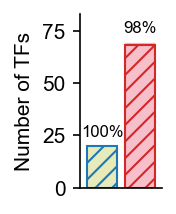

In [230]:
from ciim.src.feature_association.plots import plot_overlap
if dataset == 'CXCL9':
    figsize=(1.5, 1.5)
elif dataset == 'op':
     figsize=(.7, 1.5)
else:
    raise ValueError(f"Unknown dataset {dataset}")
plot_overlap(stats_drugs_sig, aging_stats_sig, ["CD4T"], cfg, plots_dir, agreement="opposite", figsize=figsize)
plt.title('')
plt.legend().remove()
plt.savefig(f"{plots_dir}/drug_aging_overlap_{dataset}.png", bbox_inches="tight", dpi=300, transparent=True)

## Overview

In [172]:
stats_drugs['cell_type'] = pd.Categorical(stats_drugs['cell_type'], categories=cell_types, ordered=True)

stats_drugs['trend'] = ['Increase after treatment' if x > 0 else 'Decrease after treatment' for x in stats_drugs['slope_condition']]
ctrls = stats_drugs['ctrl'].unique()

In [173]:
if False:
    from ciim.src.feature_association.plots import plot_overall_heatmap
    from ciim.src.common import palette_treatment, palette_cell_types

    stats_all_c = stats_drugs.copy()
    stats_all_c = stats_all_c.rename(columns={'slope_condition': 'slope'})
    stats_all_c = stats_all_c[stats_all_c['p_value_adj'] < 0.05]

    stats_all_c.rename(columns={'target': 'tf'}, inplace=True)
    plot_overall_heatmap(stats_all_c, 
                        sig_dots_y_offset=4, 
                        first_col='cell_type',  
                        first_col_palette=palette_cell_types,
                        second_col='comparision', 
                        second_col_palette={value: color for value, color in zip(name_mapping.values(), sns.color_palette("Set2", n_colors=len(comparision_names.values())) )},
                        trend_colors = list(palette_treatment.values()),
                        trend_names = list(palette_treatment.keys()),
                        bbox_to_anchor=(1.05, 1.07),
                        bbox_to_anchor_col1=(1.05, .82),
                        bbox_to_anchor_col2=(1.05, .38),
                        figsize=(3, 6),
                        map_names={**{'cell_type':'Cell type', 'comparision': 'Perturbation'}, **surrogate_names}, 
                        dendrogram_visible=False,
                        draw_legend=True)
    plt.savefig(f'{plots_dir}/overall_heatmap_drugs.png', bbox_inches='tight', dpi=300)

## Aging TFs

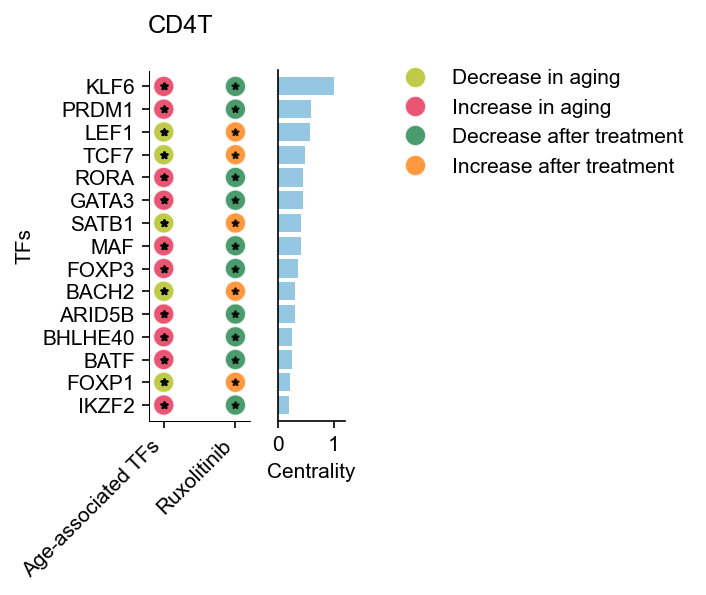

In [231]:
from ciim.src.common import palette_trend, palette_treatment
palette_all = {**palette_trend, **palette_treatment}
stats_df = stats_drugs.copy()
race = 'both'
top_aging_tfs = 15
os.makedirs(f'{plots_dir}/', exist_ok=True)
for cell_type in target_celltypes:
    # - aging tfs
    stats_aging  = retrieve_sig_stats(type=type_, race=race).drop_duplicates(subset=['tf', 'cell_type'])
    aging_df = stats_aging[stats_aging['cell_type']==cell_type]
    aging_df['analysis'] = 'Age-associated TFs'

    # - drugs
    comparisions = cfg['comparisons']
    stats_sotre = []
    for d in comparisions:
        stats_d = stats_df[(stats_df['comparision'] == d) & (stats_df['cell_type'] == cell_type)].copy()
        stats_d['is_significant'] = stats_d['p_value_adj'] < 0.05

        stats_d['analysis'] = d 
        stats_d['trend'] = ['Increase after treatment' if x > 0 else 'Decrease after treatment' for x in stats_d['slope_condition']]
        stats_sotre.append(stats_d)
    stats_condition = pd.concat(stats_sotre)

    # - subset 
    drug_tfs = stats_condition['tf'].unique()
    agings_tfs = aging_df['tf'].unique()
    common_tfs = np.intersect1d(drug_tfs, agings_tfs)
    # - merge
    df = pd.concat([aging_df, stats_condition])
    df = df[df['tf'].isin(common_tfs)]

    df['analysis'] = pd.Categorical(df['analysis'], categories=['Age-associated TFs'] + list(comparisions), ordered=True)
    # - subset the tfs
    if True:
        net = get_consensus_net(datasets_all, cell_type)
        c_df = net.groupby('source').size().reset_index(name='degree')
        df = df.merge(c_df, left_on='tf', right_on='source', how='left')

        top_tfs = df.drop_duplicates(subset=['cell_type', 'tf']).sort_values('degree', ascending=False).head(top_aging_tfs)['tf'].unique() 
        df = df[df['tf'].isin(top_tfs)].sort_values('degree', ascending=False)
    df['degree'] = df['degree'].div(df['degree'].max())  # Normalize degree
    plot_analysis_and_centrality(df, all_groups=comparisions, palette_all=palette_all, figsize=(2.5, 4), 
                            ax2_margins={'x': 0.2, 'y': 0.02}, hide_ylabels=False, plot_centrality=True, show_legend=True)
    plt.suptitle(f'{cell_type}', y=.98, weight='bold')
    plt.tight_layout()
    plt.title('')
    plt.savefig(f'{plots_dir}//aging_drug_trend_{cell_type}_{dataset}.png', bbox_inches='tight', dpi=300, transparent=True)

## Plot case TF change in perturbation

In [232]:
wrapper_tf_activity(par={
        "feature_type": feature_type,
        "datasets": [dataset],
        "cell_types": target_celltypes,
        "type": 'bulk',
        "cell_type_resolution": "cell_type",
        "association_type": "spearman",
    })

Loading data...
Calculating TF activity...
op bulk
Using layer X_norm


cell types:   0%|          | 0/1 [00:00<?, ?it/s]... storing 'dataset' as categorical
... storing 'donor_age' as categorical
cell types: 100%|██████████| 1/1 [00:09<00:00,  9.98s/it]


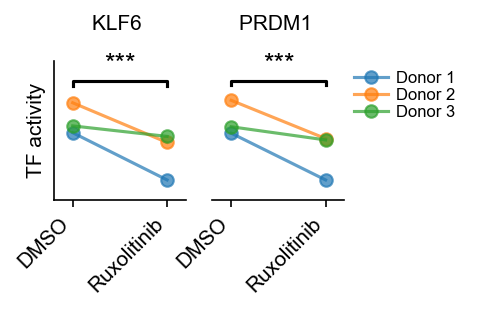

In [233]:
from ciim.src.feature_association.plots import plot_donor_level_perturbation_effect
if dataset == 'CXCL9':
    comparisions = ['Ruxolitinib (ctr: RPMI)', 'Ruxolitinib (ctr: LPS)']  # 
    bbox_to_anchor=(1, 1)
elif dataset == 'op':
    comparisions = ['Ruxolitinib']
elif dataset == 'parsebioscience':
    comparisions = ['IL-10']
else:
    raise ValueError(f'Unknown dataset {dataset}')
for comparision in comparisions:
    for cell_type in target_celltypes:
        if cell_type == 'CD4T':
            case_tfs = ['KLF6', 'PRDM1']
        elif cell_type == 'CD8T':
            case_tfs = ['LEF1', 'ZEB2']
        else:
            raise ValueError(f'Unknown cell type {cell_type}')
        fig, axes = plt.subplots(1, 2, figsize=(2.5, 1.2), sharex=False, sharey=False)
        for i, case_tf in enumerate(case_tfs):
            stats_case = stats_drugs[(stats_drugs['comparision'] == comparision) & (stats_drugs['tf'] == case_tf) & (stats_drugs['cell_type'] == cell_type)].copy()
            ax = axes[i]
            if comparision == 'Ruxolitinib (ctr: LPS)':
                ctr = '24 h LPS'
                treatment = '24 h LPS + ruxolitinib'    
            elif comparision == 'Ruxolitinib (ctr: RPMI)':
                ctr = '24 h RPMI'
                treatment = '24 h RPMI + ruxolitinib' 
            elif comparision == 'Ruxolitinib':
                ctr = 'Dimethyl Sulfoxide'
                treatment = 'Ruxolitinib'  
            elif comparision == 'IL-10':
                ctr = 'PBS'
                treatment = 'IL-10'  
            else:
                raise ValueError(f'Unknown comparision {comparision}')
            p_value_adj = stats_case['p_value_adj'].values[0] 
            plot_donor_level_perturbation_effect(case_tf, ctr, treatment, cell_type, p_value_adj, dataset=dataset, ax=ax, bbox_to_anchor=bbox_to_anchor)
            if i == 0:
                ax.get_legend().remove()  # Remove legend for the first plot
            else:
                ax.set_ylabel('', fontsize=10)
                ax.spines[['left']].set_visible(False)
        # plt.title(f'{cell_type}-{comparision}', y=1.5)
        plt.savefig(f'{plots_dir}/donor_level_perturbation_effect_{comparision}_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)

In [ ]:
aaa

NameError: name 'aaa' is not defined

## Pathway analysis

In [234]:
from ciim.src.utils.util import pathway_analysis_wrapper
pathway_scores_store = []
for ctr in stats_drugs['ctrl'].unique():
    for treatment in stats_drugs['comparision'].unique():
        stats_sig = stats_drugs[(stats_drugs['ctrl'] == ctr) & (stats_drugs['comparision'] == treatment) & (stats_drugs['p_value_adj'] < 0.05)]
        if len(stats_sig) == 0:
            continue
        pathway_scores = pathway_analysis_wrapper(stats_sig, pvalue_col='p_value_adj', gene_sets=['KEGG_2021_Human']) #'MSigDB_Hallmark_2020'
        if pathway_scores is None:
            continue
        pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])
        pathway_scores['ctrl'] = ctr
        pathway_scores['comparision'] = treatment
        pathway_scores_store.append(pathway_scores)
pathway_scores_all = pd.concat(pathway_scores_store)

KeyError: 'trend'

In [11]:
from ciim.src.feature_association.plots import dotplot_category_color
from ciim.src.common import palette_treatment

def plot_pathways_enrichment(pathway_df, title=f'metformin'):
    tfs = pathway_df['Term'].unique()
    conditions = pathway_df['comparision'].unique()
    fig, axes = plt.subplots(1, len(conditions), figsize=(2*len(conditions), len(tfs)*.2+.5), sharey=True, sharex=True)

    for i, condition in enumerate(conditions):
        ax = axes[i] if len(conditions)>1 else axes
        pathway_scores = pathway_df[pathway_df['comparision']==condition]
        if len(pathway_scores) == 0:
            continue
        # pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
        if i == len(conditions)-1:
            show_color_legend = True
            show_size_legend = True
        else:
            show_color_legend = False
            show_size_legend = False
        dotplot_category_color(pathway_scores, 
                    ax, 
                    color_col='trend', 
                    size_col='neg_log10_adj_pval', 
                    x='cell_type', 
                    y='Term', 
                    sizes=(50, 250),
                    show_color_legend=show_color_legend, 
                    show_size_legend=show_size_legend,
                    size_legend_title='Significance',
                    color_legend_title='Pathway activity',
                    size_legend_loc=(1.2, 0.35),
                    color_legend_loc=(1.02, 0.75),
                    y_label='',
                    alpha=0.5,
                    palette=palette_treatment)
        ax.set_title(condition, fontsize=10, fontweight='bold', pad=12)

    plt.suptitle(title, fontsize=12, fontweight='bold', y=1.05)
if False:
    pathway_scores_all['cell_type'] = pathway_scores_all['cell_type'].astype(CategoricalDtype(categories=cell_types, ordered=True))
    plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['ctrl']=='24 h RPMI'], title=f'RPMI')
    plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['ctrl']=='24 h LPS'], title=f'LPS')


In [ ]:

# - the term with bifurcation enrichment
term = 'TNF-alpha Signaling via NF-kB'
cell_type = 'MONO'

def explode_bifurcation_term(cell_type, term):
    pathway_scores_t = pathway_scores[
        (pathway_scores['Term'] == term) &
        (pathway_scores['cell_type'] == cell_type)
    ]
    
    if pathway_scores_t.empty:
        print(f"No data found for cell type '{cell_type}' and term '{term}'")
        return

    df = (
        pathway_scores_t
        .groupby('trend')['Genes']
        .apply(lambda x: ', '.join(x))
        .reset_index(name='Genes')
        .set_index('trend')
    )

    pp_dict = {}
    every_n_words = 5

    for trend in df.index:
        genes = df.loc[trend, 'Genes'].split(';')
        if trend == 'Increase in aging':
            wrapped = ', \n'.join(
                [', '.join(genes[i:i + every_n_words]) for i in range(0, len(genes), every_n_words)]
            )
        else:
            wrapped = ', '.join(genes)
        pp_dict[trend] = wrapped

    # Actual plot
    from matplotlib.lines import Line2D
    alpha = 0.5
    plt.figure(figsize=(0, 0))

    # Create legend handles only for present trends
    color_legend = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
               markersize=10, label=pp_dict[trend], alpha=alpha)
        for trend, color in palette_treatment.items()
        if trend in pp_dict
    ]

    legend = plt.legend(
        title=f'{cell_type}: {term}',
        title_fontsize=10,
        fontsize=10,
        handles=color_legend,
        loc=(1, .1),
        frameon=False
    )
    legend.get_title().set_fontweight('bold')
for ctr in ctrls:
    pathway_scores = pathway_scores_all[pathway_scores_all['ctrl']==ctr]
    explode_bifurcation_term(cell_type, term)



No data found for cell type 'MONO' and term 'TNF-alpha Signaling via NF-kB'
No data found for cell type 'MONO' and term 'TNF-alpha Signaling via NF-kB'


# Trajectory plot: TF acitvity with age


(981, 119)
(313, 279)
(61, 267)
(150, 113)
(981,) (981,) (981,)
(313,) (313,) (313,)
(61,) (61,) (61,)
(150,) (150,) (150,)


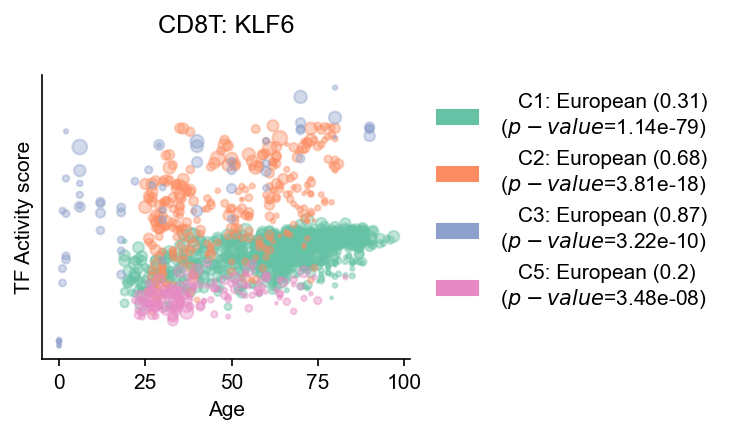

In [175]:

from ciim.src.feature_association.plots import plot_trends
from ciim.src.common import palette_datasets, datasets_e
if True:
    datasets = datasets_e
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: retrieve_adata(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets_pretty, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f'{save_dir}/tf_activity/trends_{cell_type}_case.png', dpi=300)

## TF activity trend vs expression trend in aging


In [157]:
datasets_all



['data1',
 'data7_allTPs_jalil',
 'data12',
 'SLE_European',
 'data13_Korean',
 'data13_Japanese']

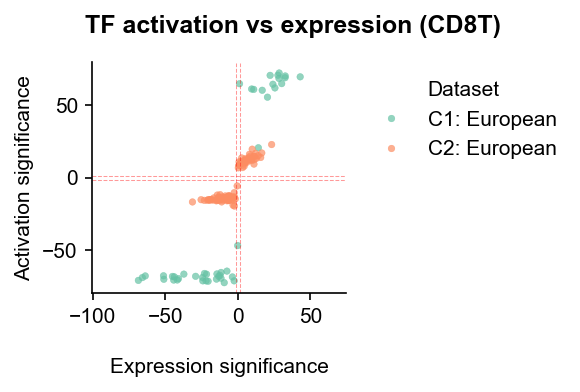

In [174]:
import numpy as np
import matplotlib.pyplot as plt
import os
from ciim.src.feature_association.plots import plot_activation_vs_expression

cell_type = 'CD8T'
os.makedirs(plots_dir, exist_ok=True)

# Retrieve TF activity stats and gene expression stats
stats_tfs = retrieve_sig_stats()
stats_targets = retrieve_sig_stats(feature_type='gene_expression')

# Merge on TF/target identity and cell_type
stats_all = stats_tfs[['cell_type', 'tf', 'slope', 'p_value_adj', 'dataset']].merge(
    stats_targets[['cell_type', 'target', 'slope', 'p_value_adj', 'dataset']],
    left_on=['cell_type', 'tf', 'dataset'],
    right_on=['cell_type', 'target', 'dataset'],
    how='inner',
    suffixes=('_source', '_target')
)

stats_all = stats_all[stats_all['dataset'].isin(['data1', 'data7_allTPs_jalil'])]
# Compute signed -log10 p-values
stats_all['Activation significance'] = np.sign(stats_all['slope_source']) * -np.log10(stats_all['p_value_adj_source'].clip(lower=1e-300))
stats_all['Expression significance'] = np.sign(stats_all['slope_target']) * -np.log10(stats_all['p_value_adj_target'].clip(lower=1e-300))

# Filter by cell type
df = stats_all[stats_all['cell_type'] == cell_type].copy()

# Plot
plot_activation_vs_expression(df,  col_x = 'Expression significance', 
                                  col_y = 'Activation significance', 
                                  y_label='Activation significance', x_label='Expression significance')
plt.suptitle(f"TF activation vs expression ({cell_type})", y=.95, fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/activation_vs_expression.png', dpi=300)